# FFNN Tanpa Hidden Layer untuk Adult Income


## Langkah 1 - Pemuatan Data



### 1.1 Import library dan konfigurasi awal


In [1]:
from pathlib import Path
import gc
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(value):
        print(value)

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)

randomSeed = 42
trainRatio = 0.8
valRatio = 0.1
numEpochs = 128
miniBatchSize = 256

useSubset = False
trainSubsetSize = 12000
valSubsetSize = 1500
testSubsetSize = 1500

inputPathCandidates = [
    Path('/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv'),
    Path('kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv'),
]

kaggleInputRoot = Path('/kaggle/input')
if kaggleInputRoot.exists():
    inputPathCandidates.extend(sorted(kaggleInputRoot.glob('**/adult.csv')))

dataPath = next((path for path in inputPathCandidates if path.exists()), None)
if dataPath is None:
    raise FileNotFoundError('File tidak ditemukan.')

outputDirCandidates = [
    Path('/kaggle/working'),
    Path('kaggle/working'),
]

outputDir = None
for candidatePath in outputDirCandidates:
    try:
        candidatePath.mkdir(parents=True, exist_ok=True)
        outputDir = candidatePath
        break
    except OSError:
        continue

if outputDir is None:
    raise OSError('Folder output tidak bisa dibuat.')

logDirCandidates = [
    Path('/kaggle/working/logs'),
    Path('kaggle/working/logs'),
]

logDir = None
for candidatePath in logDirCandidates:
    try:
        candidatePath.mkdir(parents=True, exist_ok=True)
        logDir = candidatePath
        break
    except OSError:
        continue

if logDir is None:
    raise OSError('Folder log training tidak bisa dibuat.')

print(f'Lokasi file data            : {dataPath}')
print(f'Lokasi folder output        : {outputDir}')
print(f'Lokasi folder log training  : {logDir}')


Lokasi file data            : /kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv
Lokasi folder output        : /kaggle/working
Lokasi folder log training  : /kaggle/working/logs


### 1.2 Muat dataset Adult Income


In [2]:
adultFrame = pd.read_csv(dataPath)
adultFrame.columns = [column.strip() for column in adultFrame.columns]

rawMissingMarkerCount = adultFrame.astype(str).apply(lambda column: column.str.strip().eq('?').sum()).sort_values(ascending=False)

print('Ukuran data mentah                :', adultFrame.shape)
print('Daftar kolom                      :', adultFrame.columns.tolist())
print('Jumlah penanda missing berupa ?   :', int(rawMissingMarkerCount.sum()))
print('Kolom dengan missing marker tertinggi:')
display(rawMissingMarkerCount[rawMissingMarkerCount > 0].rename('Jumlah ?').to_frame())
display(adultFrame.head())


Ukuran data mentah                : (32561, 15)
Daftar kolom                      : ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']
Jumlah penanda missing berupa ?   : 4262
Kolom dengan missing marker tertinggi:


,Jumlah ?
occupation,1843
workclass,1836
native.country,583


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Langkah 2 - Praproses Fitur Numerik dan Kategorik



### 2.1 Rumus praproses

Standardisasi fitur numerik:

$$
X_{\text{std}} = \frac{X - \mu_{\text{train}}}{\sigma_{\text{train}} + \varepsilon}
$$

One-hot encoding untuk fitur kategorik:

$$
x_{\text{kategorik}} \in \{0, 1\}^p
$$


### 2.2 Bersihkan nilai hilang dan pisahkan train-validasi-test


In [3]:
for column in adultFrame.columns:
    if adultFrame[column].dtype == object:
        adultFrame[column] = adultFrame[column].astype(str).str.strip()

adultFrame = adultFrame.replace('?', np.nan)
missingCountAfterReplace = adultFrame.isna().sum().sort_values(ascending=False)
adultFrame = adultFrame.drop_duplicates().reset_index(drop=True)

targetColumn = 'income'
featureColumns = [column for column in adultFrame.columns if column != targetColumn]
numericColumns = adultFrame[featureColumns].select_dtypes(include=[np.number]).columns.tolist()
categoricalColumns = [column for column in featureColumns if column not in numericColumns]

splitRng = np.random.default_rng(randomSeed)
shuffledIndices = splitRng.permutation(len(adultFrame))
trainEnd = int(trainRatio * len(shuffledIndices))
valEnd = int((trainRatio + valRatio) * len(shuffledIndices))

trainFrame = adultFrame.iloc[shuffledIndices[:trainEnd]].copy()
valFrame = adultFrame.iloc[shuffledIndices[trainEnd:valEnd]].copy()
testFrame = adultFrame.iloc[shuffledIndices[valEnd:]].copy()

if useSubset:
    trainFrame = trainFrame.head(trainSubsetSize).copy()
    valFrame = valFrame.head(valSubsetSize).copy()
    testFrame = testFrame.head(testSubsetSize).copy()

testFrameOriginal = testFrame.copy()

print('Jumlah data latih               :', len(trainFrame))
print('Jumlah data validasi            :', len(valFrame))
print('Jumlah data uji                 :', len(testFrame))
print('Kolom numerik                   :', numericColumns)
print('Kolom kategorik                 :', categoricalColumns)
print('Total nilai missing setelah ?->NaN :', int(missingCountAfterReplace.sum()))
print('Kolom dengan missing value setelah konversi:')
display(missingCountAfterReplace[missingCountAfterReplace > 0].rename('Jumlah Missing').to_frame())


Jumlah data latih               : 26029
Jumlah data validasi            : 3254
Jumlah data uji                 : 3254
Kolom numerik                   : ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Kolom kategorik                 : ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Total nilai missing setelah ?->NaN : 4262
Kolom dengan missing value setelah konversi:


,Jumlah Missing
occupation,1843
workclass,1836
native.country,583


### 2.3 Fungsi fit praproses


In [4]:
def fitPreprocessor(trainFrame, numericColumns, categoricalColumns):
    numericMedians = trainFrame[numericColumns].median()
    numericFilled = trainFrame[numericColumns].fillna(numericMedians)
    numericMeans = numericFilled.mean()
    numericStds = numericFilled.std().replace(0, 1.0)

    categoricalModes = trainFrame[categoricalColumns].mode(dropna=True).iloc[0]
    categoricalFilled = trainFrame[categoricalColumns].fillna(categoricalModes).astype(str)
    categoricalDummyColumns = pd.get_dummies(categoricalFilled, prefix=categoricalColumns).columns.tolist()

    return {
        'numericColumns': numericColumns,
        'categoricalColumns': categoricalColumns,
        'numericMedians': numericMedians,
        'numericMeans': numericMeans,
        'numericStds': numericStds,
        'categoricalModes': categoricalModes,
        'categoricalDummyColumns': categoricalDummyColumns,
    }


### 2.4 Fungsi transform fitur dan label


In [5]:
def transformFeatures(frame, preprocessor):
    numericFilled = frame[preprocessor['numericColumns']].fillna(preprocessor['numericMedians'])
    numericScaled = (numericFilled - preprocessor['numericMeans']) / preprocessor['numericStds']
    numericScaled = numericScaled.to_numpy(dtype=np.float32)

    categoricalFilled = frame[preprocessor['categoricalColumns']].fillna(preprocessor['categoricalModes']).astype(str)
    categoricalEncoded = pd.get_dummies(categoricalFilled, prefix=preprocessor['categoricalColumns'])
    categoricalEncoded = categoricalEncoded.reindex(columns=preprocessor['categoricalDummyColumns'], fill_value=0)
    categoricalEncoded = categoricalEncoded.to_numpy(dtype=np.float32)

    return np.concatenate([numericScaled, categoricalEncoded], axis=1)


def encodeBinaryLabels(labelSeries):
    cleanedLabels = labelSeries.astype(str).str.strip().str.replace('.', '', regex=False)
    return (cleanedLabels == '>50K').astype(np.float32).to_numpy().reshape(-1, 1)


### 2.5 Terapkan praproses ke seluruh split data


In [6]:
preprocessor = fitPreprocessor(trainFrame, numericColumns, categoricalColumns)

xTrain = transformFeatures(trainFrame[featureColumns], preprocessor)
xVal = transformFeatures(valFrame[featureColumns], preprocessor)
xTest = transformFeatures(testFrame[featureColumns], preprocessor)

yTrain = encodeBinaryLabels(trainFrame[targetColumn])
yVal = encodeBinaryLabels(valFrame[targetColumn])
yTest = encodeBinaryLabels(testFrame[targetColumn])

inputDim = xTrain.shape[1]
featureNames = preprocessor['numericColumns'] + preprocessor['categoricalDummyColumns']
normalizedNumericTrain = xTrain[:, :len(numericColumns)]
normalizedMeanSummary = np.round(normalizedNumericTrain.mean(axis=0), 4)
normalizedStdSummary = np.round(normalizedNumericTrain.std(axis=0), 4)

print('Ukuran fitur data latih        :', xTrain.shape)
print('Ukuran label data latih        :', yTrain.shape)
print('Ukuran fitur data validasi     :', xVal.shape)
print('Ukuran fitur data uji          :', xTest.shape)
print('Dimensi input                  :', inputDim)
print('Persentase label >50K latih    :', round(float(yTrain.mean()), 4))
print('Persentase label >50K uji      :', round(float(yTest.mean()), 4))
print('Rata-rata fitur numerik setelah normalisasi (train):', normalizedMeanSummary.tolist())
print('Standar deviasi fitur numerik setelah normalisasi (train):', normalizedStdSummary.tolist())


Ukuran fitur data latih        : (26029, 105)
Ukuran label data latih        : (26029, 1)
Ukuran fitur data validasi     : (3254, 105)
Ukuran fitur data uji          : (3254, 105)
Dimensi input                  : 105
Persentase label >50K latih    : 0.2408
Persentase label >50K uji      : 0.2431
Rata-rata fitur numerik setelah normalisasi (train): [0.0, 0.0, 0.0, -0.0, 0.0, 0.0]
Standar deviasi fitur numerik setelah normalisasi (train): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## Langkah 3 - Persiapan Label dan Formulasi Model


### 3.1 Rumus sigmoid, loss, dan gradien

$$
z = Xw + b
$$

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

$$
J(w,b) = -\frac{1}{m}\sum_{i=1}^{m} \left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right] + \frac{\lambda}{2}\|w\|_2^2
$$

$$
\frac{\partial J}{\partial w} = \frac{1}{m} X^\top (\hat{y} - y) + \lambda w,
\qquad
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)
$$


### 3.2 Fungsi utilitas numerik dan metrik klasifikasi biner


In [7]:
def sigmoid(logits):
    clippedLogits = np.clip(logits, -40.0, 40.0)
    return 1.0 / (1.0 + np.exp(-clippedLogits))


def binaryCrossEntropy(probabilities, labels):
    return -np.mean(labels * np.log(probabilities + 1e-12) + (1.0 - labels) * np.log(1.0 - probabilities + 1e-12))


def calculateBinaryMetrics(trueLabels, predictedLabels):
    trueLabels = trueLabels.reshape(-1)
    predictedLabels = predictedLabels.reshape(-1)

    truePositive = np.sum((trueLabels == 1) & (predictedLabels == 1))
    trueNegative = np.sum((trueLabels == 0) & (predictedLabels == 0))
    falsePositive = np.sum((trueLabels == 0) & (predictedLabels == 1))
    falseNegative = np.sum((trueLabels == 1) & (predictedLabels == 0))

    accuracy = (truePositive + trueNegative) / max(len(trueLabels), 1)
    precision = truePositive / max(truePositive + falsePositive, 1)
    recall = truePositive / max(truePositive + falseNegative, 1)
    f1Score = 2.0 * precision * recall / max(precision + recall, 1e-12)

    return {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1Score': float(f1Score),
        'truePositive': int(truePositive),
        'trueNegative': int(trueNegative),
        'falsePositive': int(falsePositive),
        'falseNegative': int(falseNegative),
    }


### 3.3 Iterator mini-batch


In [8]:
def iterateMiniBatches(xData, yData, batchSize, batchRng, shuffle=True):
    indices = np.arange(xData.shape[0])
    if shuffle:
        batchRng.shuffle(indices)

    for startIndex in range(0, xData.shape[0], batchSize):
        batchIndices = indices[startIndex:startIndex + batchSize]
        yield xData[batchIndices], yData[batchIndices]


### 3.4 Kelas model linear-sigmoid


In [9]:
class BinaryLinearClassifier:
    def __init__(self, inputDim, seed=42):
        modelRng = np.random.default_rng(seed)
        self.w = (0.01 * modelRng.standard_normal((inputDim, 1))).astype(np.float32)
        self.b = np.zeros((1, 1), dtype=np.float32)

    def getParameters(self):
        return {'w': self.w, 'b': self.b}

    def forward(self, xData):
        logits = xData @ self.w + self.b
        probabilities = sigmoid(logits)
        return logits, probabilities

    def computeLossAndGradients(self, xData, yData, weightDecay=0.0):
        logits, probabilities = self.forward(xData)
        dataLoss = binaryCrossEntropy(probabilities, yData)
        regularizationLoss = 0.5 * weightDecay * np.sum(self.w * self.w)
        totalLoss = dataLoss + regularizationLoss

        batchSize = xData.shape[0]
        delta = (probabilities - yData) / batchSize
        gradW = xData.T @ delta + weightDecay * self.w
        gradB = np.sum(delta, axis=0, keepdims=True)
        gradients = {'w': gradW.astype(np.float32), 'b': gradB.astype(np.float32)}
        return totalLoss, gradients, probabilities

    def predictProba(self, xData):
        return self.forward(xData)[1]

    def predictClass(self, xData, threshold=0.5):
        return (self.predictProba(xData) >= threshold).astype(np.float32)


## Langkah 4 - Pelatihan Model dengan Optimizer Custom



### 4.1 Rumus optimizer

#### Gradient Descent
$$
\theta_{t+1} = \theta_t - \eta g_t
$$

#### Momentum
$$
v_{t+1} = \mu v_t - \eta g_t,
\qquad
\theta_{t+1} = \theta_t + v_{t+1}
$$

#### NAG
$$
g_t = \nabla J(\theta_t + \mu v_t),
\qquad
v_{t+1} = \mu v_t - \eta g_t,
\qquad
\theta_{t+1} = \theta_t + v_{t+1}
$$

#### RMSProp
$$
r_t = \rho r_{t-1} + (1-\rho)(g_t \odot g_t),
\qquad
\theta_{t+1} = \theta_t - \eta \frac{g_t}{\sqrt{r_t} + \varepsilon}
$$

#### Adam
$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t,
\qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2)(g_t \odot g_t)
$$

$$
\hat{m}_t = \frac{m_t}{1-\beta_1^t},
\qquad
\hat{v}_t = \frac{v_t}{1-\beta_2^t}
$$

$$
\theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}
$$

#### AdamW
$$
\theta_{t+1} = (1 - \eta \lambda)\theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}
$$


### 4.2 Optimizer: Gradient Descent dan Momentum


In [10]:
class GradientDescent:
    def __init__(self, learningRate=0.05):
        self.learningRate = learningRate

    def step(self, parameters, gradients):
        for name in parameters:
            parameters[name] -= self.learningRate * gradients[name]


class Momentum:
    def __init__(self, learningRate=0.02, momentum=0.9):
        self.learningRate = learningRate
        self.momentum = momentum
        self.velocity = {}

    def step(self, parameters, gradients):
        for name, value in parameters.items():
            if name not in self.velocity:
                self.velocity[name] = np.zeros_like(value)
            self.velocity[name] = self.momentum * self.velocity[name] - self.learningRate * gradients[name]
            value += self.velocity[name]


### 4.3 Optimizer: NAG dan RMSProp


In [11]:
class NAG:
    requiresLookAhead = True

    def __init__(self, learningRate=0.02, momentum=0.9):
        self.learningRate = learningRate
        self.momentum = momentum
        self.velocity = {}
        self.cache = {}

    def beginLookAhead(self, parameters):
        self.cache = {}
        for name, value in parameters.items():
            if name not in self.velocity:
                self.velocity[name] = np.zeros_like(value)
            self.cache[name] = value.copy()
            value += self.momentum * self.velocity[name]

    def endLookAhead(self, parameters):
        for name, value in parameters.items():
            value[...] = self.cache[name]

    def step(self, parameters, gradients):
        for name, value in parameters.items():
            self.velocity[name] = self.momentum * self.velocity[name] - self.learningRate * gradients[name]
            value += self.velocity[name]


class RMSProp:
    def __init__(self, learningRate=0.001, rho=0.99, epsilon=1e-8):
        self.learningRate = learningRate
        self.rho = rho
        self.epsilon = epsilon
        self.avgSquared = {}

    def step(self, parameters, gradients):
        for name, value in parameters.items():
            if name not in self.avgSquared:
                self.avgSquared[name] = np.zeros_like(value)
            self.avgSquared[name] = self.rho * self.avgSquared[name] + (1.0 - self.rho) * (gradients[name] ** 2)
            value -= self.learningRate * gradients[name] / (np.sqrt(self.avgSquared[name]) + self.epsilon)


### 4.4 Optimizer: Adam dan AdamW


In [12]:
class Adam:
    def __init__(self, learningRate=0.003, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.learningRate = learningRate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.firstMoment = {}
        self.secondMoment = {}
        self.stepCount = 0

    def step(self, parameters, gradients):
        self.stepCount += 1
        for name, value in parameters.items():
            if name not in self.firstMoment:
                self.firstMoment[name] = np.zeros_like(value)
                self.secondMoment[name] = np.zeros_like(value)

            self.firstMoment[name] = self.beta1 * self.firstMoment[name] + (1.0 - self.beta1) * gradients[name]
            self.secondMoment[name] = self.beta2 * self.secondMoment[name] + (1.0 - self.beta2) * (gradients[name] ** 2)

            firstMomentHat = self.firstMoment[name] / (1.0 - self.beta1 ** self.stepCount)
            secondMomentHat = self.secondMoment[name] / (1.0 - self.beta2 ** self.stepCount)
            value -= self.learningRate * firstMomentHat / (np.sqrt(secondMomentHat) + self.epsilon)


class AdamW:
    def __init__(self, learningRate=0.003, beta1=0.9, beta2=0.999, epsilon=1e-8, weightDecay=1e-4, decayParameters=('w',)):
        self.learningRate = learningRate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.weightDecay = weightDecay
        self.decayParameters = set(decayParameters)
        self.firstMoment = {}
        self.secondMoment = {}
        self.stepCount = 0

    def step(self, parameters, gradients):
        self.stepCount += 1
        for name, value in parameters.items():
            if name not in self.firstMoment:
                self.firstMoment[name] = np.zeros_like(value)
                self.secondMoment[name] = np.zeros_like(value)

            self.firstMoment[name] = self.beta1 * self.firstMoment[name] + (1.0 - self.beta1) * gradients[name]
            self.secondMoment[name] = self.beta2 * self.secondMoment[name] + (1.0 - self.beta2) * (gradients[name] ** 2)

            firstMomentHat = self.firstMoment[name] / (1.0 - self.beta1 ** self.stepCount)
            secondMomentHat = self.secondMoment[name] / (1.0 - self.beta2 ** self.stepCount)

            if name in self.decayParameters:
                value *= (1.0 - self.learningRate * self.weightDecay)
            value -= self.learningRate * firstMomentHat / (np.sqrt(secondMomentHat) + self.epsilon)


## Langkah 5 - Evaluasi dan Training


### 5.1 Rumus metrik klasifikasi biner

$$
\mathrm{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

$$
\mathrm{Precision} = \frac{TP}{TP + FP}
\qquad
\mathrm{Recall} = \frac{TP}{TP + FN}
$$

$$
\mathrm{F1} = \frac{2 \cdot \mathrm{Precision} \cdot \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}}
$$


### 5.2 Fungsi evaluasi model


In [13]:
def evaluateModel(model, xData, yData, weightDecay=0.0):
    _, probabilities = model.forward(xData)
    loss = binaryCrossEntropy(probabilities, yData) + 0.5 * weightDecay * np.sum(model.w * model.w)
    predictions = (probabilities >= 0.5).astype(np.float32)
    metrics = calculateBinaryMetrics(yData, predictions)
    return float(loss), metrics, predictions, probabilities


### 5.3 Fungsi training satu eksperimen


In [14]:
def trainOneExperiment(config, xTrain, yTrain, xVal, yVal):
    model = BinaryLinearClassifier(inputDim=inputDim, seed=randomSeed)
    optimizer = config['optimizerFactory']()
    batchRng = np.random.default_rng(randomSeed)
    history = {
        'epoch': [],
        'trainLoss': [],
        'trainAccuracy': [],
        'trainF1': [],
        'valLoss': [],
        'valAccuracy': [],
        'valF1': [],
        'epochTime': [],
    }

    bestValF1 = -np.inf
    bestEpoch = -1
    bestParameters = None
    totalStartTime = time.perf_counter()
    logLines = []

    for epochIndex in range(1, config['numEpochs'] + 1):
        epochStartTime = time.perf_counter()

        for xBatch, yBatch in iterateMiniBatches(xTrain, yTrain, config['batchSize'], batchRng, shuffle=True):
            parameters = model.getParameters()

            if getattr(optimizer, 'requiresLookAhead', False):
                optimizer.beginLookAhead(parameters)
                _, gradients, _ = model.computeLossAndGradients(xBatch, yBatch, weightDecay=config['lossWeightDecay'])
                optimizer.endLookAhead(parameters)
            else:
                _, gradients, _ = model.computeLossAndGradients(xBatch, yBatch, weightDecay=config['lossWeightDecay'])

            optimizer.step(parameters, gradients)

        trainLoss, trainMetrics, _, _ = evaluateModel(model, xTrain, yTrain, weightDecay=config['lossWeightDecay'])
        valLoss, valMetrics, _, _ = evaluateModel(model, xVal, yVal, weightDecay=config['lossWeightDecay'])
        epochTime = time.perf_counter() - epochStartTime

        history['epoch'].append(epochIndex)
        history['trainLoss'].append(trainLoss)
        history['trainAccuracy'].append(trainMetrics['accuracy'])
        history['trainF1'].append(trainMetrics['f1Score'])
        history['valLoss'].append(valLoss)
        history['valAccuracy'].append(valMetrics['accuracy'])
        history['valF1'].append(valMetrics['f1Score'])
        history['epochTime'].append(epochTime)

        if valMetrics['f1Score'] > bestValF1:
            bestValF1 = valMetrics['f1Score']
            bestEpoch = epochIndex
            bestParameters = {name: value.copy() for name, value in model.getParameters().items()}

        epochLogLine = (
            f"[{config['name']}] epoch {epochIndex:02d}/{config['numEpochs']} "
            f"loss latih={trainLoss:.4f} akurasi latih={trainMetrics['accuracy']:.4f} f1 latih={trainMetrics['f1Score']:.4f} "
            f"loss validasi={valLoss:.4f} akurasi validasi={valMetrics['accuracy']:.4f} f1 validasi={valMetrics['f1Score']:.4f} waktu={epochTime:.2f} detik"
        )
        logLines.append(epochLogLine)
        print(epochLogLine)

    if bestParameters is not None:
        parameters = model.getParameters()
        for name in parameters:
            parameters[name][...] = bestParameters[name]

    totalTime = time.perf_counter() - totalStartTime
    return model, history, bestEpoch, float(bestValF1), float(totalTime), logLines


### 5.4 Konfigurasi eksperimen optimizer


In [15]:
def buildExperimentConfigs(trainSize):
    l2WeightDecay = 1e-4
    return [
        {
            'name': 'Batch GD',
            'optimizerFactory': lambda: GradientDescent(learningRate=0.05),
            'batchSize': trainSize,
            'numEpochs': numEpochs,
            'lossWeightDecay': l2WeightDecay,
        },
        {
            'name': 'Mini-Batch GD',
            'optimizerFactory': lambda: GradientDescent(learningRate=0.03),
            'batchSize': miniBatchSize,
            'numEpochs': numEpochs,
            'lossWeightDecay': l2WeightDecay,
        },
        {
            'name': 'Momentum',
            'optimizerFactory': lambda: Momentum(learningRate=0.02, momentum=0.9),
            'batchSize': miniBatchSize,
            'numEpochs': numEpochs,
            'lossWeightDecay': l2WeightDecay,
        },
        {
            'name': 'NAG',
            'optimizerFactory': lambda: NAG(learningRate=0.02, momentum=0.9),
            'batchSize': miniBatchSize,
            'numEpochs': numEpochs,
            'lossWeightDecay': l2WeightDecay,
        },
        {
            'name': 'RMSProp',
            'optimizerFactory': lambda: RMSProp(learningRate=0.001, rho=0.99),
            'batchSize': miniBatchSize,
            'numEpochs': numEpochs,
            'lossWeightDecay': l2WeightDecay,
        },
        {
            'name': 'Adam',
            'optimizerFactory': lambda: Adam(learningRate=0.003),
            'batchSize': miniBatchSize,
            'numEpochs': numEpochs,
            'lossWeightDecay': l2WeightDecay,
        },
        {
            'name': 'AdamW',
            'optimizerFactory': lambda: AdamW(learningRate=0.003, weightDecay=1e-4),
            'batchSize': miniBatchSize,
            'numEpochs': numEpochs,
            'lossWeightDecay': 0.0,
        },
    ]


experimentConfigs = buildExperimentConfigs(len(xTrain))
pd.DataFrame(
    [
        {
            'Optimizer': config['name'],
            'Ukuran Batch': config['batchSize'],
            'Jumlah Epoch': config['numEpochs'],
            'Peluruhan Bobot pada Loss': config['lossWeightDecay'],
        }
        for config in experimentConfigs
    ]
)


,Optimizer,Ukuran Batch,Jumlah Epoch,Peluruhan Bobot pada Loss
0,Batch GD,26029,128,0.0001
1,Mini-Batch GD,256,128,0.0001
2,Momentum,256,128,0.0001
3,NAG,256,128,0.0001
4,RMSProp,256,128,0.0001
5,Adam,256,128,0.0001
6,AdamW,256,128,0.0000


### 5.5 Jalankan semua eksperimen


In [16]:
trainedModels = {}
allHistories = {}
optimizerLogPaths = {}
summaryRows = []

for config in experimentConfigs:
    print('\n' + '=' * 80)
    print(f"Mulai pelatihan dengan optimizer: {config['name']}")

    model, history, bestEpoch, bestValF1, totalTime, logLines = trainOneExperiment(
        config,
        xTrain,
        yTrain,
        xVal,
        yVal,
    )

    testLoss, testMetrics, testPredictions, testProbabilities = evaluateModel(
        model,
        xTest,
        yTest,
        weightDecay=config['lossWeightDecay'],
    )

    optimizerFileName = config['name'].lower().replace(' ', '_').replace('-', '_') + '.txt'
    optimizerLogPath = logDir / optimizerFileName
    logLines.append('')
    logLines.append(f"Epoch terbaik         : {bestEpoch}")
    logLines.append(f"F1 validasi terbaik   : {bestValF1:.4f}")
    logLines.append(f"Loss data uji         : {testLoss:.4f}")
    logLines.append(f"Akurasi data uji      : {testMetrics['accuracy']:.4f}")
    logLines.append(f"Precision data uji    : {testMetrics['precision']:.4f}")
    logLines.append(f"Recall data uji       : {testMetrics['recall']:.4f}")
    logLines.append(f"F1 data uji           : {testMetrics['f1Score']:.4f}")
    logLines.append(f"Waktu total           : {totalTime:.2f} detik")
    optimizerLogPath.write_text('\n'.join(logLines) + '\n', encoding='utf-8')

    trainedModels[config['name']] = model
    allHistories[config['name']] = history
    optimizerLogPaths[config['name']] = optimizerLogPath
    summaryRows.append(
        {
            'Optimizer': config['name'],
            'Ukuran Batch': config['batchSize'],
            'Epoch Terbaik': bestEpoch,
            'F1 Validasi Terbaik': bestValF1,
            'Loss Data Uji': testLoss,
            'Akurasi Test': testMetrics['accuracy'],
            'Precision Test': testMetrics['precision'],
            'Recall Test': testMetrics['recall'],
            'F1 Test': testMetrics['f1Score'],
            'Waktu Total (detik)': totalTime,
        }
    )

    print(f"Log training disimpan di: {optimizerLogPath}")

summaryTable = pd.DataFrame(summaryRows).sort_values(by='F1 Validasi Terbaik', ascending=False).reset_index(drop=True)
for column in ['F1 Validasi Terbaik', 'Loss Data Uji', 'Akurasi Test', 'Precision Test', 'Recall Test', 'F1 Test']:
    summaryTable[column] = summaryTable[column].map(lambda value: round(value, 4))
summaryTable['Waktu Total (detik)'] = summaryTable['Waktu Total (detik)'].map(lambda value: round(value, 2))
summaryTable



Mulai pelatihan dengan optimizer: Batch GD
[Batch GD] epoch 01/128 loss latih=0.6737 akurasi latih=0.7735 f1 latih=0.1948 loss validasi=0.6739 akurasi validasi=0.7723 f1 validasi=0.1919 waktu=0.02 detik
[Batch GD] epoch 02/128 loss latih=0.6573 akurasi latih=0.7694 f1 latih=0.0936 loss validasi=0.6575 akurasi validasi=0.7674 f1 validasi=0.0712 waktu=0.03 detik
[Batch GD] epoch 03/128 loss latih=0.6425 akurasi latih=0.7674 f1 latih=0.0706 loss validasi=0.6426 akurasi validasi=0.7674 f1 validasi=0.0573 waktu=0.02 detik
[Batch GD] epoch 04/128 loss latih=0.6290 akurasi latih=0.7663 f1 latih=0.0602 loss validasi=0.6291 akurasi validasi=0.7667 f1 validasi=0.0548 waktu=0.02 detik
[Batch GD] epoch 05/128 loss latih=0.6168 akurasi latih=0.7660 f1 latih=0.0573 loss validasi=0.6168 akurasi validasi=0.7667 f1 validasi=0.0548 waktu=0.02 detik
[Batch GD] epoch 06/128 loss latih=0.6056 akurasi latih=0.7658 f1 latih=0.0555 loss validasi=0.6055 akurasi validasi=0.7667 f1 validasi=0.0548 waktu=0.02 de

,Optimizer,Ukuran Batch,Epoch Terbaik,F1 Validasi Terbaik,Loss Data Uji,Akurasi Test,Precision Test,Recall Test,F1 Test,Waktu Total (detik)
0,Adam,256,46,0.6757,0.3319,0.8454,0.7057,0.6245,0.6626,5.09
1,AdamW,256,86,0.6757,0.3315,0.8457,0.7055,0.6271,0.6640,4.97
2,Momentum,256,86,0.6744,0.3316,0.8442,0.7011,0.6258,0.6613,4.61
3,NAG,256,86,0.6744,0.3315,0.8445,0.7027,0.6245,0.6613,4.59
4,RMSProp,256,86,0.6676,0.3312,0.8485,0.7224,0.6119,0.6626,4.70
5,Mini-Batch GD,256,128,0.6615,0.3309,0.8430,0.7147,0.5891,0.6459,4.13
6,Batch GD,26029,128,0.5234,0.3986,0.8162,0.7359,0.3805,0.5017,2.51


## Langkah 6 - Evaluasi dan Ringkasan Performa Optimizer


### 6.1 Kurva loss dan F1 validasi


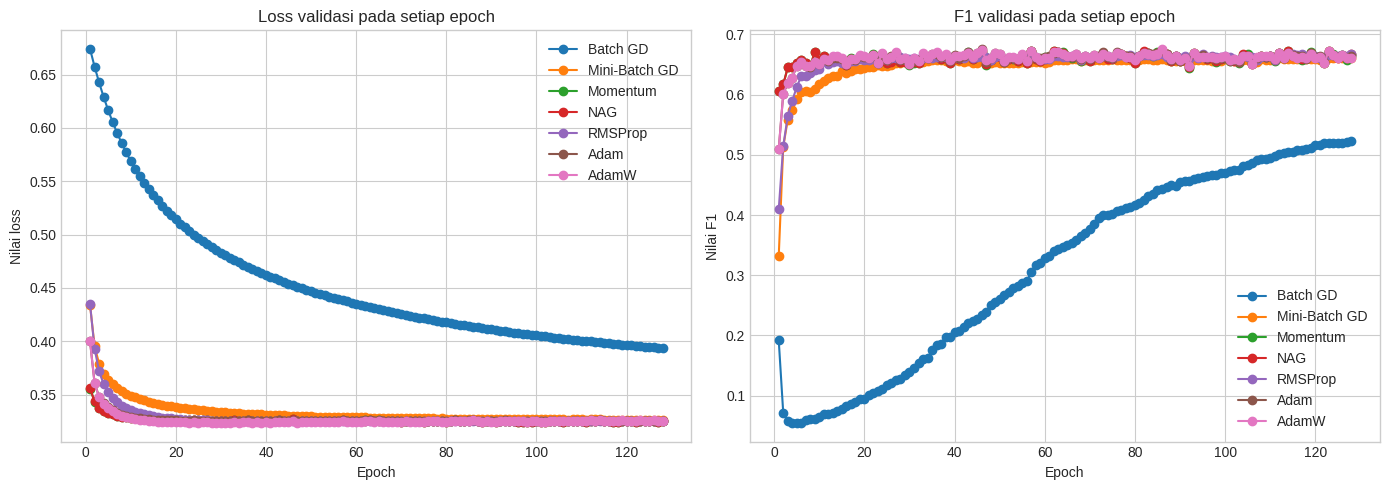

Grafik validasi disimpan di: /kaggle/working/adult_validation_curves.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for optimizerName, history in allHistories.items():
    axes[0].plot(history['epoch'], history['valLoss'], marker='o', label=optimizerName)
    axes[1].plot(history['epoch'], history['valF1'], marker='o', label=optimizerName)

axes[0].set_title('Loss validasi pada setiap epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Nilai loss')

axes[1].set_title('F1 validasi pada setiap epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Nilai F1')

for ax in axes:
    ax.legend()

plt.tight_layout()
validationCurvePath = outputDir / 'adult_validation_curves.png'
fig.savefig(validationCurvePath, dpi=200, bbox_inches='tight')
plt.show()
print(f'Grafik validasi disimpan di: {validationCurvePath}')


### 6.2 Confusion matrix optimizer terbaik


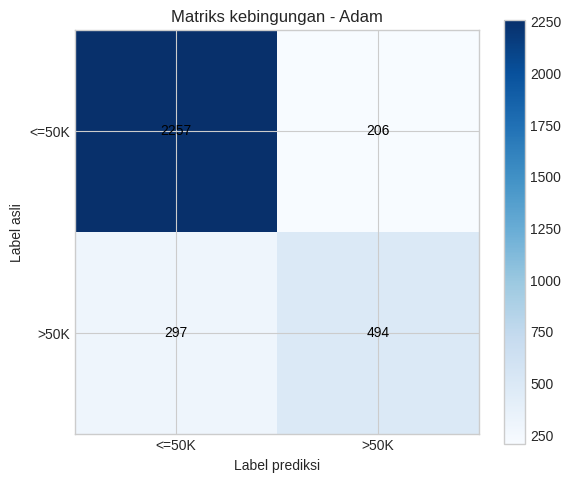

Matriks kebingungan disimpan di: /kaggle/working/adult_confusion_matrix_best_optimizer.png


In [18]:
def computeConfusionMatrix(trueLabels, predictedLabels):
    trueLabels = trueLabels.reshape(-1)
    predictedLabels = predictedLabels.reshape(-1)
    return np.array([
        [np.sum((trueLabels == 0) & (predictedLabels == 0)), np.sum((trueLabels == 0) & (predictedLabels == 1))],
        [np.sum((trueLabels == 1) & (predictedLabels == 0)), np.sum((trueLabels == 1) & (predictedLabels == 1))],
    ])


bestOptimizerName = summaryTable.iloc[0]['Optimizer']
bestModel = trainedModels[bestOptimizerName]
testLossBest, testMetricsBest, bestTestPredictions, bestTestProbabilities = evaluateModel(bestModel, xTest, yTest)
confusionMatrix = computeConfusionMatrix(yTest, bestTestPredictions)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusionMatrix, cmap='Blues')
ax.set_title(f'Matriks kebingungan - {bestOptimizerName}')
ax.set_xlabel('Label prediksi')
ax.set_ylabel('Label asli')
ax.set_xticks([0, 1])
ax.set_xticklabels(['<=50K', '>50K'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['<=50K', '>50K'])

for rowIndex in range(2):
    for colIndex in range(2):
        ax.text(colIndex, rowIndex, int(confusionMatrix[rowIndex, colIndex]), ha='center', va='center', color='black')

plt.colorbar(image, ax=ax)
plt.tight_layout()
confusionMatrixImagePath = outputDir / 'adult_confusion_matrix_best_optimizer.png'
fig.savefig(confusionMatrixImagePath, dpi=200, bbox_inches='tight')
plt.show()
print(f'Matriks kebingungan disimpan di: {confusionMatrixImagePath}')


### 6.3 Tabel perbandingan optimizer dan file output


In [19]:
binaryMetricTable = pd.DataFrame({
    'Metrik': ['Akurasi', 'Precision', 'Recall', 'F1'],
    'Nilai': [
        round(testMetricsBest['accuracy'], 4),
        round(testMetricsBest['precision'], 4),
        round(testMetricsBest['recall'], 4),
        round(testMetricsBest['f1Score'], 4),
    ],
})

summaryTablePath = outputDir / 'adult_summary_optimizer_comparison.csv'
binaryMetricTablePath = outputDir / 'adult_best_optimizer_metrics.csv'
confusionMatrixCsvPath = outputDir / 'adult_confusion_matrix_best_optimizer.csv'
confusionMatrixNpyPath = outputDir / 'adult_confusion_matrix_best_optimizer.npy'

summaryTable.to_csv(summaryTablePath, index=False)
binaryMetricTable.to_csv(binaryMetricTablePath, index=False)
pd.DataFrame(confusionMatrix, index=['<=50K', '>50K'], columns=['<=50K', '>50K']).to_csv(confusionMatrixCsvPath)
np.save(confusionMatrixNpyPath, confusionMatrix)

print('Tabel perbandingan optimizer:')
display(summaryTable)

print('Metrik optimizer terbaik pada data uji:')
display(binaryMetricTable)

print(f'File ringkasan optimizer disimpan di: {summaryTablePath}')
print(f'File metrik optimizer terbaik disimpan di: {binaryMetricTablePath}')
print(f'File matriks kebingungan CSV disimpan di: {confusionMatrixCsvPath}')
print(f'File matriks kebingungan NPY disimpan di: {confusionMatrixNpyPath}')

print('File log training per optimizer:')
for optimizerName, logPath in optimizerLogPaths.items():
    print(f'- {optimizerName}: {logPath}')


Tabel perbandingan optimizer:


,Optimizer,Ukuran Batch,Epoch Terbaik,F1 Validasi Terbaik,Loss Data Uji,Akurasi Test,Precision Test,Recall Test,F1 Test,Waktu Total (detik)
0,Adam,256,46,0.6757,0.3319,0.8454,0.7057,0.6245,0.6626,5.09
1,AdamW,256,86,0.6757,0.3315,0.8457,0.7055,0.6271,0.6640,4.97
2,Momentum,256,86,0.6744,0.3316,0.8442,0.7011,0.6258,0.6613,4.61
3,NAG,256,86,0.6744,0.3315,0.8445,0.7027,0.6245,0.6613,4.59
4,RMSProp,256,86,0.6676,0.3312,0.8485,0.7224,0.6119,0.6626,4.70
5,Mini-Batch GD,256,128,0.6615,0.3309,0.8430,0.7147,0.5891,0.6459,4.13
6,Batch GD,26029,128,0.5234,0.3986,0.8162,0.7359,0.3805,0.5017,2.51


Metrik optimizer terbaik pada data uji:


,Metrik,Nilai
0,Akurasi,0.8454
1,Precision,0.7057
2,Recall,0.6245
3,F1,0.6626


File ringkasan optimizer disimpan di: /kaggle/working/adult_summary_optimizer_comparison.csv
File metrik optimizer terbaik disimpan di: /kaggle/working/adult_best_optimizer_metrics.csv
File matriks kebingungan CSV disimpan di: /kaggle/working/adult_confusion_matrix_best_optimizer.csv
File matriks kebingungan NPY disimpan di: /kaggle/working/adult_confusion_matrix_best_optimizer.npy
File log training per optimizer:
- Batch GD: /kaggle/working/logs/batch_gd.txt
- Mini-Batch GD: /kaggle/working/logs/mini_batch_gd.txt
- Momentum: /kaggle/working/logs/momentum.txt
- NAG: /kaggle/working/logs/nag.txt
- RMSProp: /kaggle/working/logs/rmsprop.txt
- Adam: /kaggle/working/logs/adam.txt
- AdamW: /kaggle/working/logs/adamw.txt


### 6.4 Contoh prediksi pada data uji


In [20]:
exampleCount = min(10, len(testFrameOriginal))
exampleIndices = np.arange(exampleCount)
exampleProbabilities = bestModel.predictProba(xTest[exampleIndices]).reshape(-1)
examplePredictions = (exampleProbabilities >= 0.5).astype(int)

examplePredictionTable = testFrameOriginal.iloc[exampleIndices][['age', 'education', 'occupation', 'hours.per.week', 'income']].copy()
examplePredictionTable = examplePredictionTable.rename(columns={
    'age': 'Usia',
    'education': 'Pendidikan',
    'occupation': 'Pekerjaan',
    'hours.per.week': 'Jam Kerja per Minggu',
    'income': 'Label Asli',
})
examplePredictionTable['Label Prediksi'] = np.where(examplePredictions == 1, '>50K', '<=50K')
examplePredictionTable['Probabilitas >50K'] = np.round(exampleProbabilities, 4)

examplePredictionTablePath = outputDir / 'adult_example_predictions.csv'
examplePredictionTable.to_csv(examplePredictionTablePath, index=False)

print('Contoh prediksi data uji:')
display(examplePredictionTable)
print(f'Tabel contoh prediksi disimpan di: {examplePredictionTablePath}')


Contoh prediksi data uji:


,Usia,Pendidikan,Pekerjaan,Jam Kerja per Minggu,Label Asli,Label Prediksi,Probabilitas >50K
28023,32,10th,Craft-repair,40,<=50K,<=50K,0.0095
29834,61,Some-college,Sales,40,<=50K,<=50K,0.0866
14266,30,10th,NaN,40,<=50K,<=50K,0.0174
29388,48,HS-grad,Handlers-cleaners,16,>50K,<=50K,0.1305
7025,41,HS-grad,Craft-repair,40,<=50K,<=50K,0.0441
23902,41,Bachelors,Tech-support,38,<=50K,>50K,0.6461
12821,31,HS-grad,Adm-clerical,50,<=50K,<=50K,0.3815
15974,22,Some-college,Tech-support,20,<=50K,<=50K,0.0096
6232,56,7th-8th,Transport-moving,20,<=50K,<=50K,0.0133
15103,24,Some-college,Other-service,40,<=50K,<=50K,0.0164


Tabel contoh prediksi disimpan di: /kaggle/working/adult_example_predictions.csv
